In [1]:
import numpy as np
from cvxopt import matrix, solvers

solvers.options['show_progress'] = False


class OneClassSVM_RBF:
    def __init__(self, nu=0.1, gamma=1.0):
        self.nu = nu
        self.gamma = gamma

    def rbf_kernel(self, X1, X2):
        sq1 = np.sum(X1**2, axis=1).reshape(-1, 1)
        sq2 = np.sum(X2**2, axis=1).reshape(1, -1)
        sqdist = sq1 + sq2 - 2 * X1 @ X2.T
        return np.exp(-self.gamma * sqdist)

    def fit(self, X):
        n = X.shape[0]
        K = self.rbf_kernel(X, X)

        P = matrix(K)
        q = matrix(np.zeros(n))

        G_std = np.vstack((
            -np.eye(n),
            np.eye(n)
        ))

        h_std = np.hstack((
            np.zeros(n),
            np.ones(n) / (self.nu * n)
        ))

        A = matrix(np.ones((1, n)))
        b = matrix(1.0)

        solution = solvers.qp(P, q, matrix(G_std), matrix(h_std), A, b)

        self.alpha = np.ravel(solution['x'])
        self.X_train = X

        # Compute rho
        support = (self.alpha > 1e-6)
        idx = np.where(support)[0][0]
        self.rho = np.sum(self.alpha * K[:, idx])

    def decision_function(self, X):
        K = self.rbf_kernel(self.X_train, X)
        return (self.alpha @ K) - self.rho

    def premise_loss(self, X):
        f = self.decision_function(X)
        return np.maximum(0, -f)


In [20]:
import numpy as np
from cvxopt import matrix, solvers

solvers.options['show_progress'] = False


class OneClassSVM_Primal:
    def __init__(self, nu=0.1, feature_map=None):
        self.nu = nu
        self.feature_map = feature_map if feature_map is not None else self.identity_map

    def identity_map(self, X):
        return X

    def fit(self, X):
        Phi = self.feature_map(X)
        n, d = Phi.shape
        
        # Variables: [w (d), rho (1), xi (n)]
        total_vars = d + 1 + n
        
        P = np.zeros((total_vars, total_vars))
        P[:d, :d] = np.eye(d)  # 1/2 ||w||^2
        
        q = np.zeros(total_vars)
        q[d] = -1  # -rho
        q[d+1:] = 1 / (self.nu * n)  # slack penalty
        
        # Constraints:
        # w^T Phi_i - rho + xi_i >= 0
        # xi_i >= 0
        
        G = []
        h = []
        
        # First constraint
        for i in range(n):
            row = np.zeros(total_vars)
            row[:d] = -Phi[i]
            row[d] = 1
            row[d+1+i] = -1
            G.append(row)
            h.append(0)
        
        # Slack positivity
        for i in range(n):
            row = np.zeros(total_vars)
            row[d+1+i] = -1
            G.append(row)
            h.append(0)
        
        G = matrix(np.array(G, dtype='double'))
        h = matrix(np.array(h, dtype='double').reshape(-1,1))
        P = matrix(P, tc='d')
        q = matrix(q, tc='d')

        solution = solvers.qp(P, q, G, h)
        
        sol = np.array(solution['x']).flatten()
        
        self.w = sol[:d]
        self.rho = sol[d]
        self.Phi_train = Phi

    def decision_function(self, X):
        Phi = self.feature_map(X)
        return Phi @ self.w - self.rho

    def premise_loss(self, X):
        f = self.decision_function(X)
        return np.maximum(0, -f)


In [25]:
def feature_map(X):
    x1 = X[:, 0:1]
    x2 = X[:, 1:2]
    return np.hstack([
        x1,
        x2,
        x1 * x2,
        x1**2,
        x2**2
    ])


In [2]:
# Generate synthetic data
X = np.random.randn(200, 2)

model = OneClassSVM_RBF(nu=0.1, gamma=1.0)
model.fit(X)

# Test some new points
X_test = np.random.randn(10, 2)
loss = model.premise_loss(X_test)
print(loss)


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [3]:
import numpy as np

def generate_ring(n_samples=300, noise=0.05, radius=2.0, seed=0):
    rng = np.random.default_rng(seed)
    
    angles = rng.uniform(0, 2*np.pi, n_samples)
    r = radius + rng.normal(0, noise, n_samples)
    
    x1 = r * np.cos(angles)
    x2 = r * np.sin(angles)
    
    X = np.vstack([x1, x2]).T
    return X


In [7]:
import matplotlib.pyplot as plt

def plot_ocsvm(model, X, grid_size=200):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6,6))
    
    # Filled region
    plt.contourf(xx, yy, Z >= 0, alpha=0.2)
    
    # Decision boundary
    plt.contour(xx, yy, Z, levels=[0], linewidths=2)
    
    # Data
    plt.scatter(X[:,0], X[:,1], s=10)
    
    plt.title("One-Class SVM (RBF)")
    plt.axis("equal")
    plt.show()


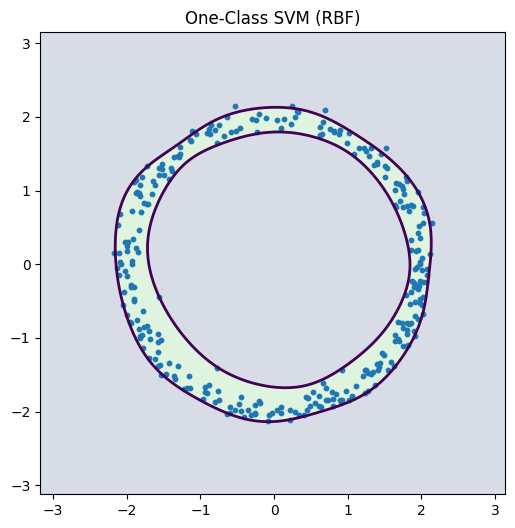

In [38]:
X = generate_ring(n_samples=300, noise=0.1, radius=2.0)
model = OneClassSVM_RBF(nu=0.1, gamma=1.0)
model.fit(X)
plot_ocsvm(model, X)

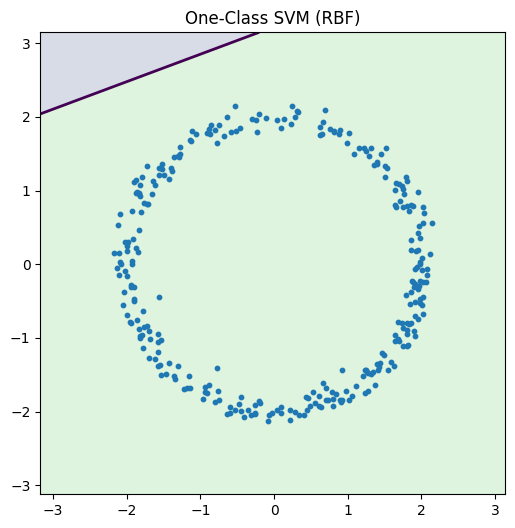

In [31]:
X = generate_ring(n_samples=300, noise=0.1)

model = OneClassSVM_Primal(nu=0.1)
model.fit(X)

plot_ocsvm(model, X)


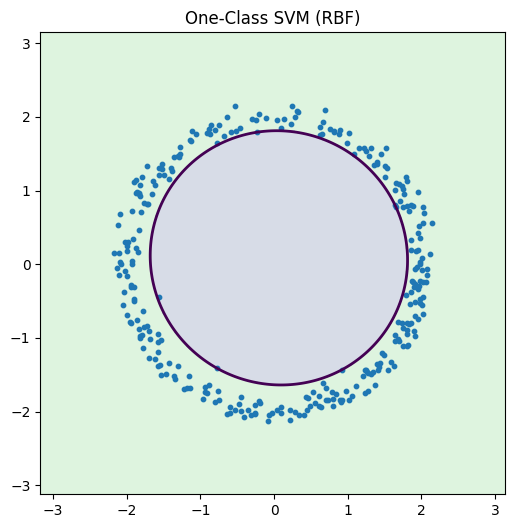

In [29]:
model = OneClassSVM_Primal(nu=0.01, feature_map=feature_map)
model.fit(X)

plot_ocsvm(model, X)


In [34]:
import torch
import torch.nn as nn

class SVMPremise(nn.Module):
    def __init__(self, support_vectors, alpha, rho, gamma):
        super().__init__()
        
        self.support_vectors = torch.tensor(support_vectors, dtype=torch.float32)
        self.alpha = torch.tensor(alpha.flatten(), dtype=torch.float32)
        self.rho = torch.tensor(rho, dtype=torch.float32)
        self.gamma = gamma

    def rbf_kernel(self, X1, X2):
        sq1 = (X1**2).sum(dim=1, keepdim=True)
        sq2 = (X2**2).sum(dim=1, keepdim=True)
        sqdist = sq1 + sq2.T - 2 * X1 @ X2.T
        return torch.exp(-self.gamma * sqdist)

    def forward(self, X):
        K = self.rbf_kernel(self.support_vectors, X)
        f = self.alpha @ K - self.rho
        return torch.relu(-f)  # penalty
